In [27]:
import pandas as pd
df=pd.read_csv('simulated_agent_4000T.csv')
print(df.head())
print(df['Block'].unique())

   Trial  Block Conflict Trial_Type  Cue_Valence  Optimal_Action  \
0      1  B1_MC       PI         NW            1               0   
1      2  B1_MC       PI         NW            1               0   
2      3  B1_MC       PI         NW            1               0   
3      4  B1_MC       PI         NW            1               0   
4      5  B1_MC       PC        NAL           -1               0   

   Agent_Choice  Agent_Reward  Correct  
0           1.0           0.0        0  
1           1.0           0.0        0  
2           1.0           0.0        0  
3           1.0           0.0        0  
4           1.0          -1.0        0  
<StringArray>
['B1_MC', 'B2_HC', 'B4_LC']
Length: 3, dtype: str


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

In [19]:
# Action - Outcome pairs are observables
obs_map = {
    (0, -1): 0,
    (0,  0): 1,
    (0,  1): 2,
    (1, -1): 3,
    (1,  0): 4,
    (1,  1): 5,
}

df['choice_reward'] = list(zip(df['Agent_Choice'].astype(int), df['Agent_Reward'].astype(int)))
df['obs'] = df['choice_reward'].map(obs_map)
print(df['obs'].head(10))


0    4
1    4
2    4
3    4
4    3
5    4
6    4
7    4
8    4
9    1
Name: obs, dtype: int64


In [22]:
from hmmlearn import hmm
import numpy as np

# prepare observation sequence — hmmlearn needs a 2D array
obs_seq = df['obs'].values.reshape(-1, 1)

# fit HMM with 3 hidden states
model = hmm.CategoricalHMM(n_components=3, n_iter=10000, random_state=42)
model.fit(obs_seq)

,n_components,3
,n_features,np.int64(6)
,random_state,RandomState(M...0x7F4991FC1D40
,n_iter,10000
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,algorithm,'viterbi'
,tol,0.01
,verbose,False
,params,'ste'


In [26]:
print("Transition matrix:")
print(model.transmat_.round(3))

print("\nEmission probabilities:")
print(model.emissionprob_.round(3))

print("\nInitial state probabilities:")
print(model.startprob_.round(3))

df.groupby(['Block', 'hmm_state']).size()

Transition matrix:
[[0.    1.    0.   ]
 [0.995 0.    0.005]
 [0.002 0.001 0.996]]

Emission probabilities:
[[0.026 0.275 0.084 0.067 0.262 0.288]
 [0.014 0.3   0.097 0.039 0.215 0.335]
 [0.055 0.145 0.184 0.032 0.429 0.156]]

Initial state probabilities:
[0. 0. 1.]


Block  hmm_state
B1_MC  0            284
       1            285
       2            431
B2_HC  0              2
       1              2
       2            996
B4_LC  0            500
       1            500
dtype: int64

state 0 - 1 = 1.00
state 1 - 0 = 0.99
state 2 - 2 = 0.99


state 1 - 2 = 0.005

- So when in state 0 always transition to state 1. Never persist for more than a time step
- From state 1 always transition back to state 0, Another transient state
 - very rarely transition from 1 to 2
- When in state 2, remains in itself. 

In [1]:
# Viterbi Algo
hidden_states = model.predict(obs_seq)
print(hidden_states[:50])
model.decode(obs_seq, algorithm="viterbi")
hidden_states = model.predict(obs_seq)

print("State changes:")
prev_state = hidden_states[0]

# Print when there is a state change
# for i in range(1, len(hidden_states)):
#     if hidden_states[i] != prev_state:
#         print(f"Trial {i}: State {prev_state} → State {hidden_states[i]}")
#         prev_state = hidden_states[i]


NameError: name 'model' is not defined

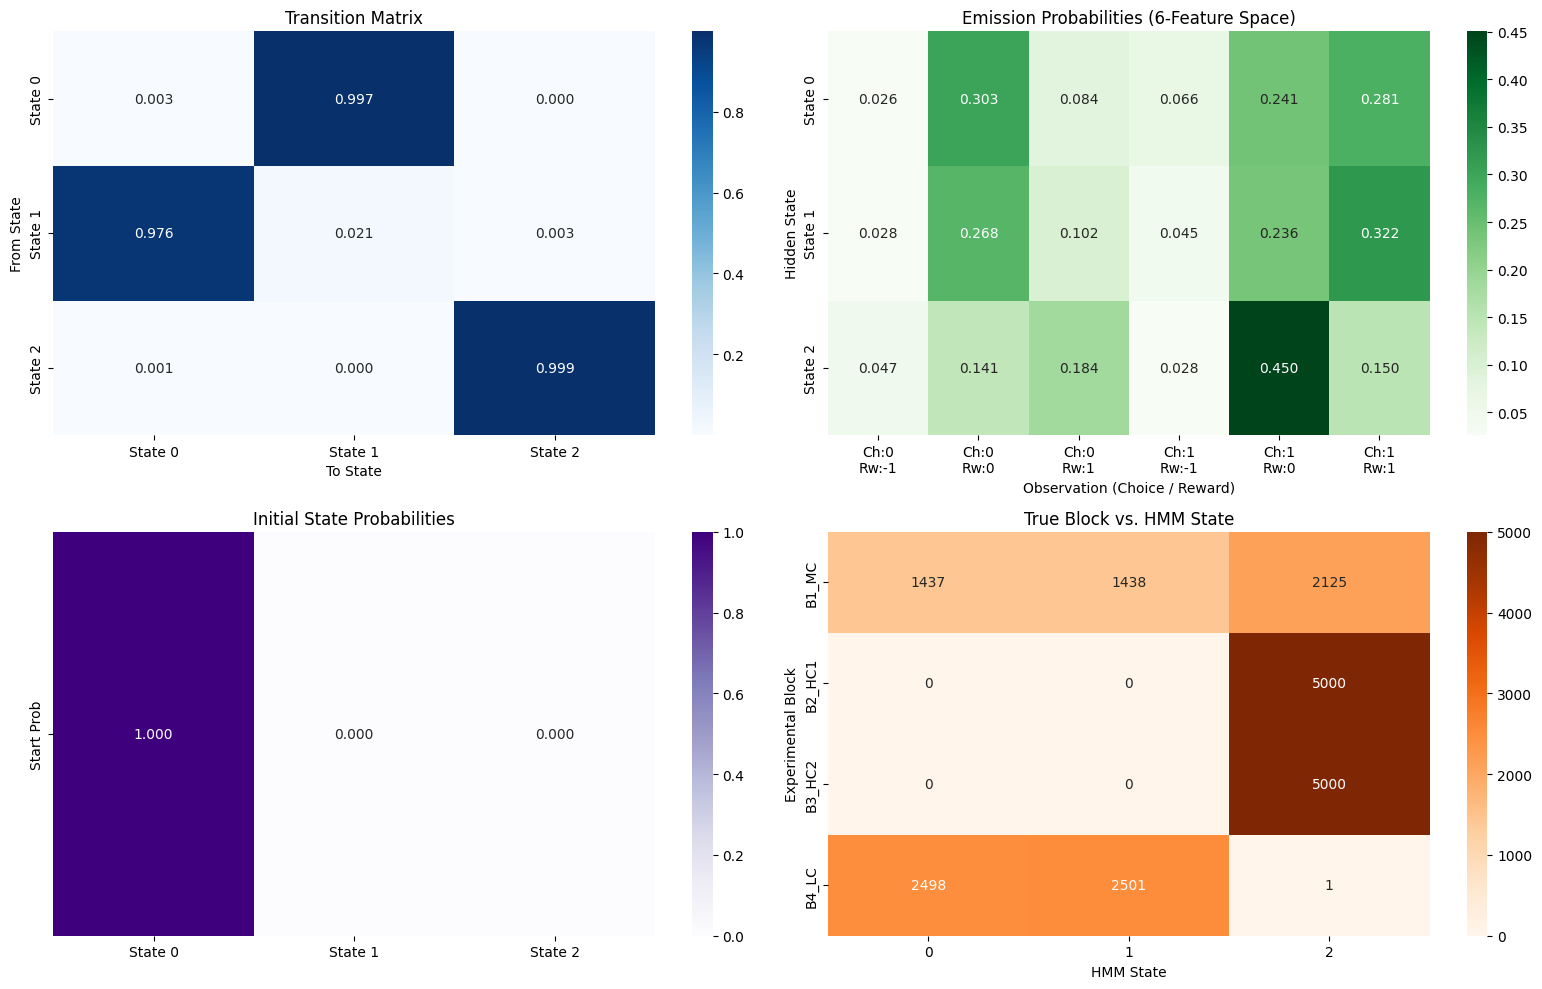

In [28]:
## I am not responsible for this ai garbage

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Crosstab dataframe
crosstab_df = df.groupby(['Block', 'hmm_state']).size().unstack(fill_value=0)

# 2. Generate clean labels for the 6 observations dynamically from your obs_map
# This formats the tuples like "Ch:0\nRw:-1" for a cleaner X-axis
obs_labels = [f"Ch:{k[0]}\nRw:{k[1]}" for k in obs_map.keys()]

# 3. Set up a 2x2 grid for the heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Plot A: Transition Matrix ---
sns.heatmap(model.transmat_, annot=True, cmap='Blues', fmt='.3f', ax=axes[0, 0],
            xticklabels=['State 0', 'State 1', 'State 2'],
            yticklabels=['State 0', 'State 1', 'State 2'])
axes[0, 0].set_title('Transition Matrix')
axes[0, 0].set_xlabel('To State')
axes[0, 0].set_ylabel('From State')

# --- Plot B: Emission Probabilities ---
sns.heatmap(model.emissionprob_, annot=True, cmap='Greens', fmt='.3f', ax=axes[0, 1],
            xticklabels=obs_labels,
            yticklabels=['State 0', 'State 1', 'State 2'])
axes[0, 1].set_title('Emission Probabilities (6-Feature Space)')
axes[0, 1].set_xlabel('Observation (Choice / Reward)')
axes[0, 1].set_ylabel('Hidden State')

# --- Plot C: Initial State Probabilities ---
sns.heatmap(model.startprob_.reshape(1, -1), annot=True, cmap='Purples', fmt='.3f', ax=axes[1, 0],
            xticklabels=['State 0', 'State 1', 'State 2'],
            yticklabels=['Start Prob'])
axes[1, 0].set_title('Initial State Probabilities')

# --- Plot D: True Block vs. HMM State (Crosstab) ---
# fmt='d' is used to display integers instead of decimals for trial counts
sns.heatmap(crosstab_df, annot=True, cmap='Oranges', fmt='d', ax=axes[1, 1])
axes[1, 1].set_title('True Block vs. HMM State')
axes[1, 1].set_xlabel('HMM State')
axes[1, 1].set_ylabel('Experimental Block')

# 4. Adjust layout and display
plt.tight_layout()
plt.show()

# map hmm states to block labels based on what we observed
# state_to_block = [0: 'LC', 1: 'LC', 2: 'HC']
## Categorical hmm: 3 hidden states, observations(agent_choice, agent_reward)
- Perfect classification of HC1 and HC2

- States 0 and 1 (low and medium conflicts), couldnt be separated from each other.
- Both have emission probability being the highest for GW.

- Since MC and LC differ only in proportion of PC vs PI trials. Their average reward patterns are too similar ot distinsguih with choice reward alone

- Raw behavior can easily separate HC and LC/MC.

- So we are adding cue valence information into our HMM.


In [8]:
## Adding cue valence to this
print(df['Cue_Valence'].unique())
print(df['Agent_Choice'].unique())
print(df['Agent_Reward'].unique())

[-1  1]
[1. 0.]
[-1.  1.  0.]


In [9]:
df['state'] = hidden_states

print(pd.crosstab(
    df['state'],
    df['Conflict'],
    margins=True
))

Conflict    PC     PI    All
state                       
0         2559   1376   3935
1         2497   1442   3939
2         3944   8182  12126
All       9000  11000  20000


In [29]:
## Inference using cue-pc/pi, choice-gng & rewards
# Format: (Agent_Choice, Agent_Reward, Cue_Valence)
obs_map3 = {
    # --- Choice 0 (e.g., No-Go) ---
    (0, -1, -1): 0,   # Choice 0, Reward -1, Cue -1
    (0, -1,  1): 1,   # Choice 0, Reward -1, Cue  1
    (0,  0, -1): 2,   # Choice 0, Reward  0, Cue -1
    (0,  0,  1): 3,   # Choice 0, Reward  0, Cue  1
    (0,  1, -1): 4,   # Choice 0, Reward  1, Cue -1
    (0,  1,  1): 5,   # Choice 0, Reward  1, Cue  1

    # --- Choice 1 (e.g., Go) ---
    (1, -1, -1): 6,   # Choice 1, Reward -1, Cue -1
    (1, -1,  1): 7,   # Choice 1, Reward -1, Cue  1
    (1,  0, -1): 8,   # Choice 1, Reward  0, Cue -1
    (1,  0,  1): 9,   # Choice 1, Reward  0, Cue  1
    (1,  1, -1): 10,  # Choice 1, Reward  1, Cue -1
    (1,  1,  1): 11   # Choice 1, Reward  1, Cue  1
}

# Now you can just map it directly like before:
# df3['obs_tuple'] = list(zip(df3['Agent_Choice'].astype(int), df3['Agent_Reward'].astype(int), df3['Cue_Valence'].astype(int)))
# df3['obs'] = df3['obs_tuple'].map(obs_map3)

In [30]:
obs_seq3 = df3['obs'].values.reshape(-1, 1)

model3 = hmm.CategoricalHMM(
    n_components=3,
    n_iter=100,
    random_state=42
)

model3.fit(obs_seq3)

,n_components,3
,n_features,np.int64(8)
,random_state,RandomState(M...0x7F5AD045BA40
,n_iter,100
,startprob_prior,1.0
,transmat_prior,1.0
,emissionprob_prior,1.0
,algorithm,'viterbi'
,tol,0.01
,verbose,False
,params,'ste'


In [35]:
df3['hidden_state'] = model3.predict(obs_seq3)

In [36]:
print(df3['hidden_state'].value_counts().sort_index())

hidden_state
0    5918
1    5922
2    8160
Name: count, dtype: int64


In [38]:
# 1. Crosstab
# Note: By default, a basic crosstab outputs integers (counts), but if you 
# are using normalize=True or just want to be safe, .round(2) handles it:
# Print initial basic outputs
print("State Distribution:")
print(df3['hidden_state'].value_counts().sort_index())

crosstab_result = pd.crosstab(df3['hidden_state'], df3['Block'], margins=True).round(2)
print("\nCrosstab:")
print(crosstab_result)
# 2. Emission probabilities
print("Emission Probabilities:")
print(model3.emissionprob_.round(2))

# 3. Transition matrix
print("\nTransition Matrix:")
print(model3.transmat_.round(2))

State Distribution:
hidden_state
0    5918
1    5922
2    8160
Name: count, dtype: int64

Crosstab:
Block         B1_MC  B2_HC1  B3_HC2  B4_LC    All
hidden_state                                     
0               920    2499    2499      0   5918
1               920    2501    2501      0   5922
2              3160       0       0   5000   8160
All            5000    5000    5000   5000  20000
Emission Probabilities:
[[0.03 0.2  0.01 0.15 0.14 0.14 0.04 0.28]
 [0.03 0.16 0.01 0.15 0.12 0.17 0.06 0.3 ]
 [0.06 0.09 0.02 0.3  0.27 0.08 0.03 0.15]]

Transition Matrix:
[[0.   1.   0.  ]
 [0.98 0.02 0.  ]
 [0.   0.   1.  ]]


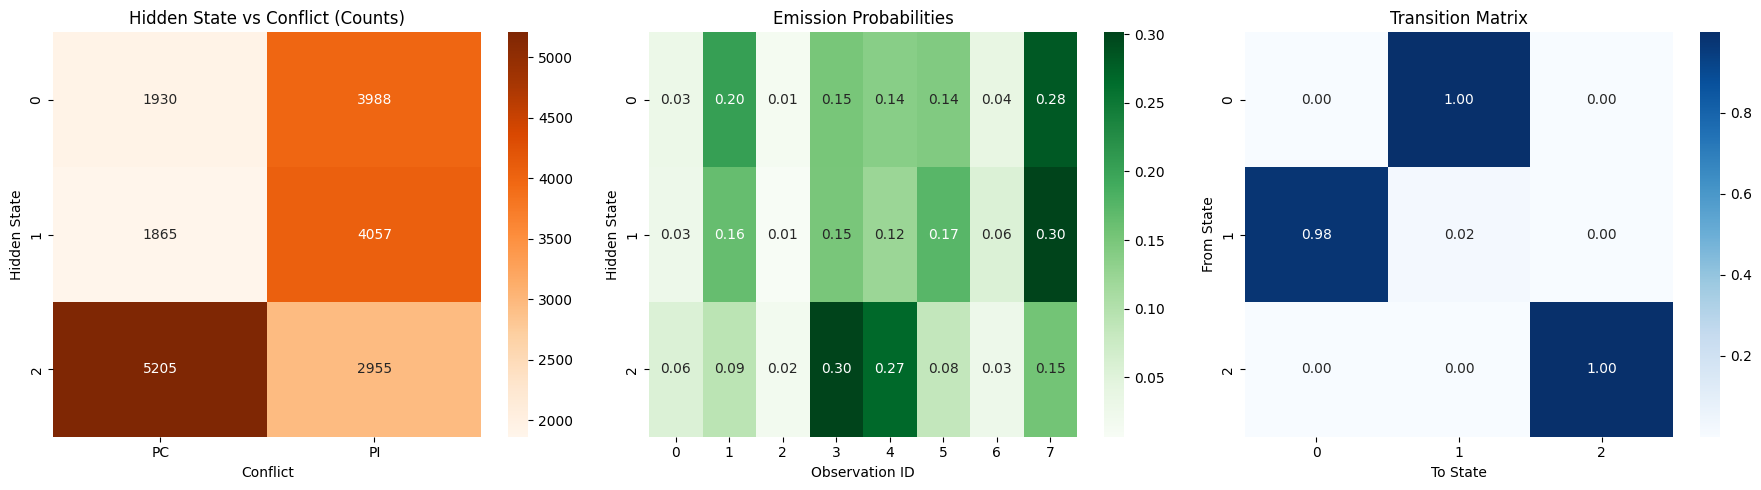

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Prepare the Crosstab (excluding margins so the color scale remains accurate)
crosstab_heatmap_data = pd.crosstab(df3['hidden_state'], df3['Conflict'])

# 2. Set up a 1x3 grid for the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot A: Hidden State vs. Conflict (Crosstab) ---
# Using fmt='d' for integers (trial counts)
sns.heatmap(crosstab_heatmap_data, annot=True, cmap='Oranges', fmt='d', ax=axes[0])
axes[0].set_title('Hidden State vs Conflict (Counts)')
axes[0].set_xlabel('Conflict')
axes[0].set_ylabel('Hidden State')

# --- Plot B: Emission Probabilities ---
# Using fmt='.2f' to match your 2 decimal place rounding
sns.heatmap(model3.emissionprob_, annot=True, cmap='Greens', fmt='.2f', ax=axes[1])
axes[1].set_title('Emission Probabilities')
axes[1].set_xlabel('Observation ID')
axes[1].set_ylabel('Hidden State')

# --- Plot C: Transition Matrix ---
# Using fmt='.2f' for probabilities
sns.heatmap(model3.transmat_, annot=True, cmap='Blues', fmt='.2f', ax=axes[2])
axes[2].set_title('Transition Matrix')
axes[2].set_xlabel('To State')
axes[2].set_ylabel('From State')

# 3. Adjust layout and display
plt.tight_layout()
plt.show()